In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))


Report: unique
       Category  Unique Count
0  Constructors           211
1       Drivers           861
2         Races          1125

Report: missing
       Category Missing values
0  Constructors             {}
1       Drivers             {}
2         Races             {}

Report: duplicates
       Category  Duplicate Count
0  Constructors                0
1       Drivers                0
2         Races                0


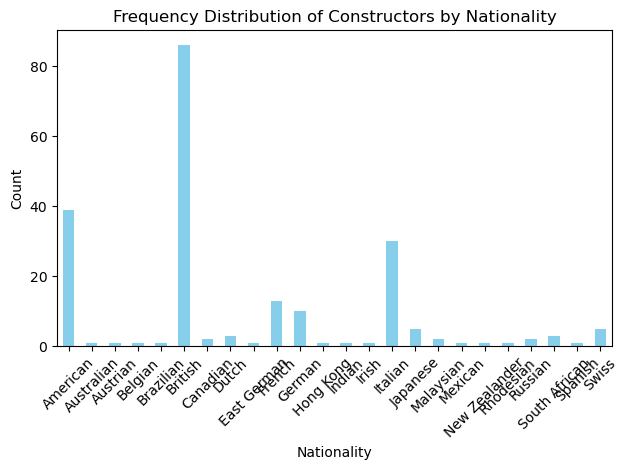

      nationality  Count
0        American     39
1      Australian      1
2        Austrian      1
3         Belgian      1
4       Brazilian      1
5         British     86
6        Canadian      2
7           Dutch      3
8     East German      1
9          French     13
10         German     10
11      Hong Kong      1
12         Indian      1
13          Irish      1
14        Italian     30
15       Japanese      5
16      Malaysian      2
17        Mexican      1
18  New Zealander      1
19      Rhodesian      1
20        Russian      2
21  South African      3
22        Spanish      1
23          Swiss      5
 Merge step 1: on raceId → shape: (26759, 35)
 Merge step 2: on driverId → shape: (26759, 43)
 Merge step 3: on constructorId → shape: (26759, 47)
 Merge step 4: on ['raceId', 'driverId'] → shape: (26759, 54)


In [2]:
from src.data.data_preprocess import masterdata
from src.data.analysis import Top3Analyser


In [3]:
sorted(masterdata.columns)

['circuitId',
 'code',
 'constructorId_x',
 'constructorId_y',
 'constructorRef',
 'constructor_name',
 'date',
 'dob',
 'driverId',
 'driverRef',
 'fastestLap',
 'fastestLapSpeed',
 'fastestLapTime',
 'forename',
 'fp1_date',
 'fp1_time',
 'fp2_date',
 'fp2_time',
 'fp3_date',
 'fp3_time',
 'gp_name',
 'grid',
 'laps',
 'milliseconds',
 'nationality_x',
 'nationality_y',
 'number_x',
 'points',
 'positionOrder',
 'positionText',
 'q1',
 'q2',
 'q3',
 'quali_date',
 'quali_time',
 'qualifyId',
 'qualifying_position',
 'raceId',
 'race_position',
 'race_start',
 'race_time',
 'rank',
 'resultId',
 'round',
 'sprint_date',
 'sprint_time',
 'statusId',
 'surname',
 'top3',
 'url_constructor',
 'url_driver',
 'url_gp',
 'year']

In [4]:
# columns to delete or rename
cols = masterdata.columns

x_cols = [col for col in cols if col.endswith('_x')]
y_cols = [col for col in cols if col.endswith('_y')]

common_prefixes = set()
for x in x_cols:
    base = x[:-2]  # убираем "_x"
    if f"{base}_y" in y_cols:
        common_prefixes.add(base)

print("(x/y):", sorted(common_prefixes))

(x/y): ['constructorId', 'nationality']


In [5]:
for col in sorted(common_prefixes):
    x_col = f"{col}_x"
    y_col = f"{col}_y"
    x_val = masterdata[x_col].iloc[1] if x_col in masterdata.columns else None
    y_val = masterdata[y_col].iloc[1] if y_col in masterdata.columns else None
    print(f"{col}: x = {x_val}, y = {y_val}")

constructorId: x = 2, y = 2.0
nationality: x = German, y = German


we should delete "constructor_Id", 'number' and 'number_y

also rename column
name_x = gp_name
name_y = constructor_name

position_x = race_position

position_y = qualifying_position

time_x = race_time

time_y = race_start

url = url_constructor

url_x = url_gp

url_y = url_driver


In [37]:
masterdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 54 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId_x  26759 non-null  int64  
 4   number_x         26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position_x       26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time_x           26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    